In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [2]:
df=pd.read_csv("/content/drive/MyDrive/Data set/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


DATA QUALITY CHECK


In [4]:
print("Shape:", df.shape)

df.info()

df.isnull().sum()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


Fix TotalCharges

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

**EDA** **SECTION**

Churn Distribution

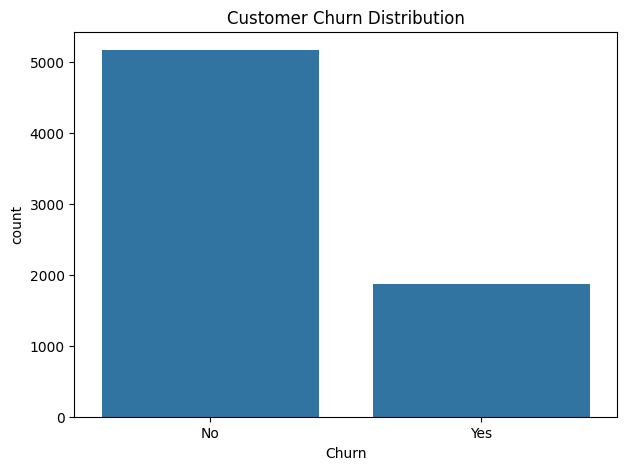

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

Contract Type

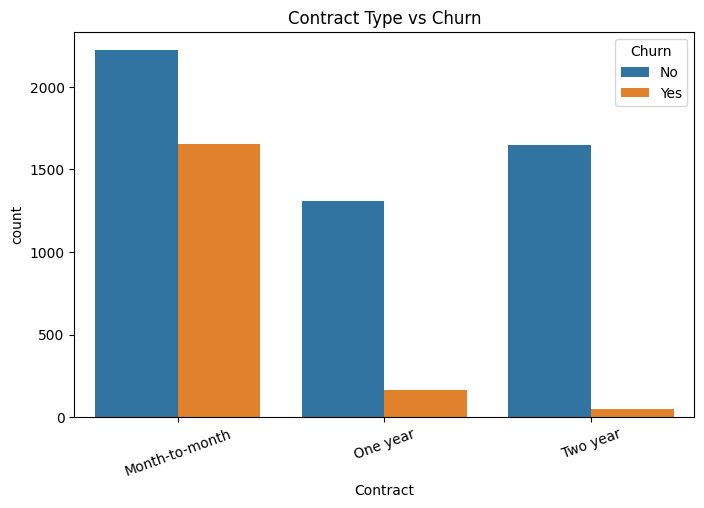

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()

Monthly Charges Distribution

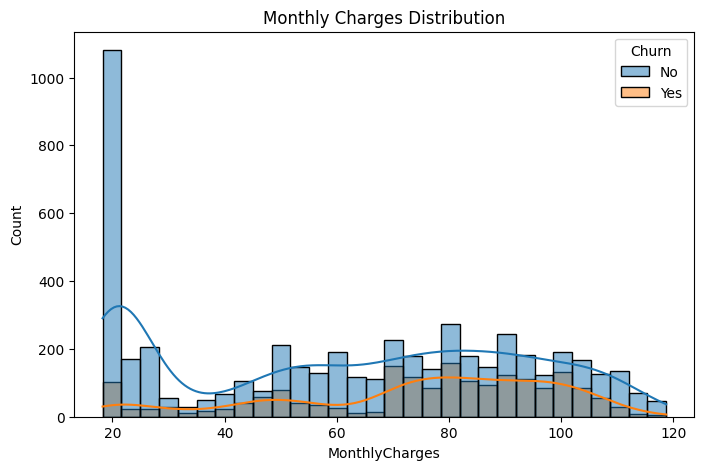

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    kde=True,
    bins=30
)

plt.title("Monthly Charges Distribution")
plt.show()

Tenure vs Churn

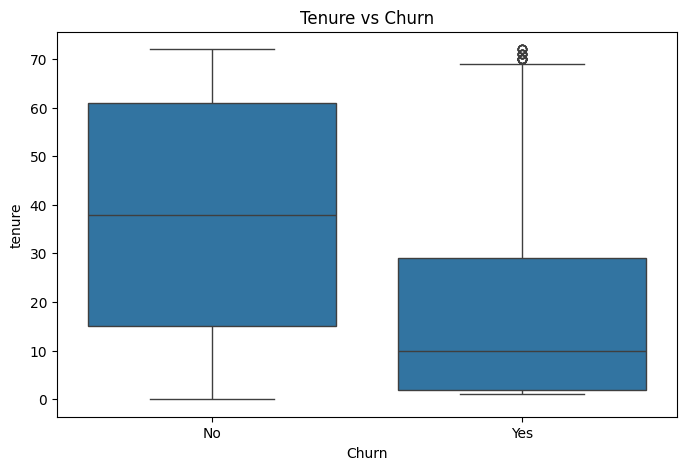

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title("Tenure vs Churn")
plt.show()

Payment Method Analysis

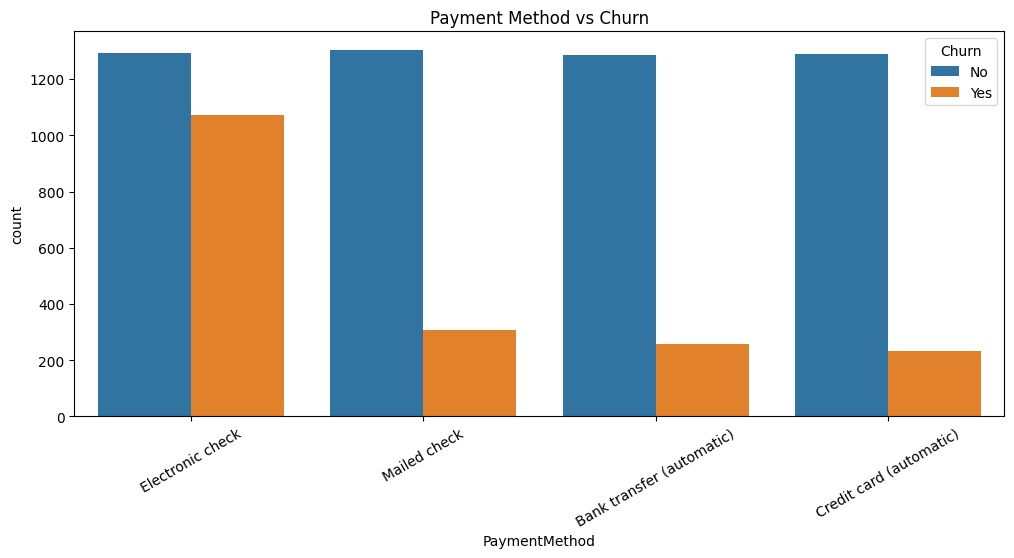

In [12]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.xticks(rotation=30)
plt.title("Payment Method vs Churn")
plt.show()

Internet Service Analysis

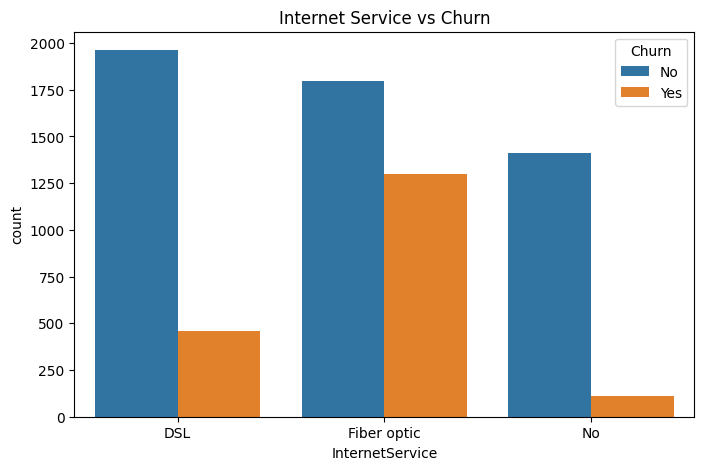

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title("Internet Service vs Churn")
plt.show()

Churn Heatmap

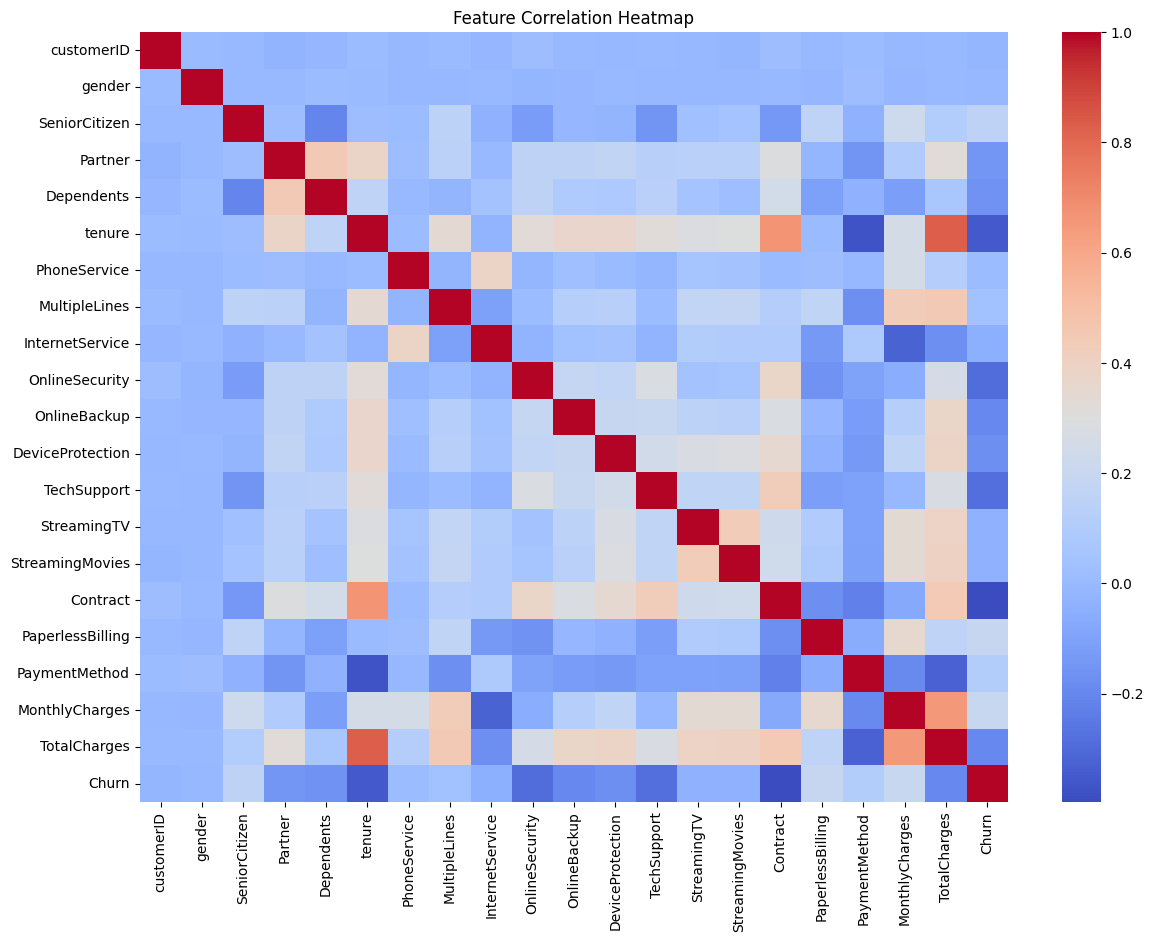

In [14]:
temp = df.copy()

for col in temp.select_dtypes('object').columns:
    temp[col] = LabelEncoder().fit_transform(temp[col])

plt.figure(figsize=(14,10))
sns.heatmap(
    temp.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

Revenue Analysis

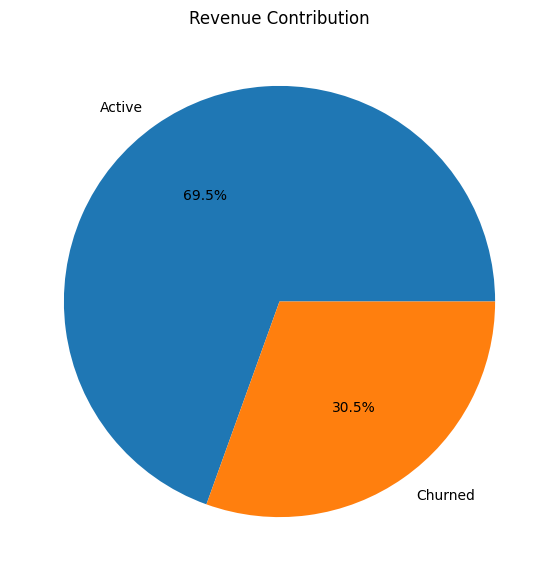

In [15]:
churned_revenue = df[df['Churn']=='Yes']['MonthlyCharges'].sum()
active_revenue = df[df['Churn']=='No']['MonthlyCharges'].sum()
plt.figure(figsize=(7,7))

plt.pie(
    [active_revenue,churned_revenue],
    labels=['Active','Churned'],
    autopct='%1.1f%%'
)

plt.title("Revenue Contribution")
plt.show()

**FEATURE** **ENGINEERING**

Customer Lifetime Value

In [16]:
df['CLV'] = df['MonthlyCharges'] * df['tenure']

Average Monthly Spend

In [17]:
df['AvgMonthlySpend'] = (
    df['TotalCharges'] /
    (df['tenure'] + 1)
)

Encode Target

In [18]:
df['Churn'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

Label Encoding

In [19]:
le = LabelEncoder()

for col in df.select_dtypes('object').columns:
    df[col] = le.fit_transform(df[col])

**TRAIN** **TEST** **SPLIT**

In [20]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**MODEL** **TRAINING**

Logistic Regression

In [21]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



Random Forest

In [22]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



XGBoost

In [23]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train,y_train)
xgb_pred = xgb.predict(X_test)
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**MODEL** **COMPARISON**

In [24]:
models = ['Logistic','Random Forest','XGBoost']

scores = [
    accuracy_score(y_test,lr_pred),
    accuracy_score(y_test,rf_pred),
    accuracy_score(y_test,xgb_pred)
]

comparison = pd.DataFrame({
    'Model':models,
    'Accuracy':scores
})

comparison

,Model,Accuracy
0,Logistic,0.801278
1,Random Forest,0.786373
2,XGBoost,0.789212
